# Predictive Maintenance Data Preprocessing and Modeling\nThis notebook handles data loading, EDA, feature extraction, and ML modeling for the Hydraulic Systems dataset.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')


## 1. Load Target Labels (Profile)

In [50]:
# Load profile.csv which contains target labels
# Columns: 1: Cooler condition, 2: Valve condition, 3: Internal pump leakage, 4: Hydraulic accumulator, 5: stable flag
profile_path = 'Datasets/profile.csv'
profile = pd.read_csv(profile_path, sep='\t', header=None)
profile.columns = ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Hydraulic_Accumulator', 'Stable_Flag']
print(f"Profile shape: {profile.shape}")
display(profile.head())


Profile shape: (2205, 5)


,Cooler_Condition,Valve_Condition,Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


## 2. Exploratory Data Analysis (EDA)

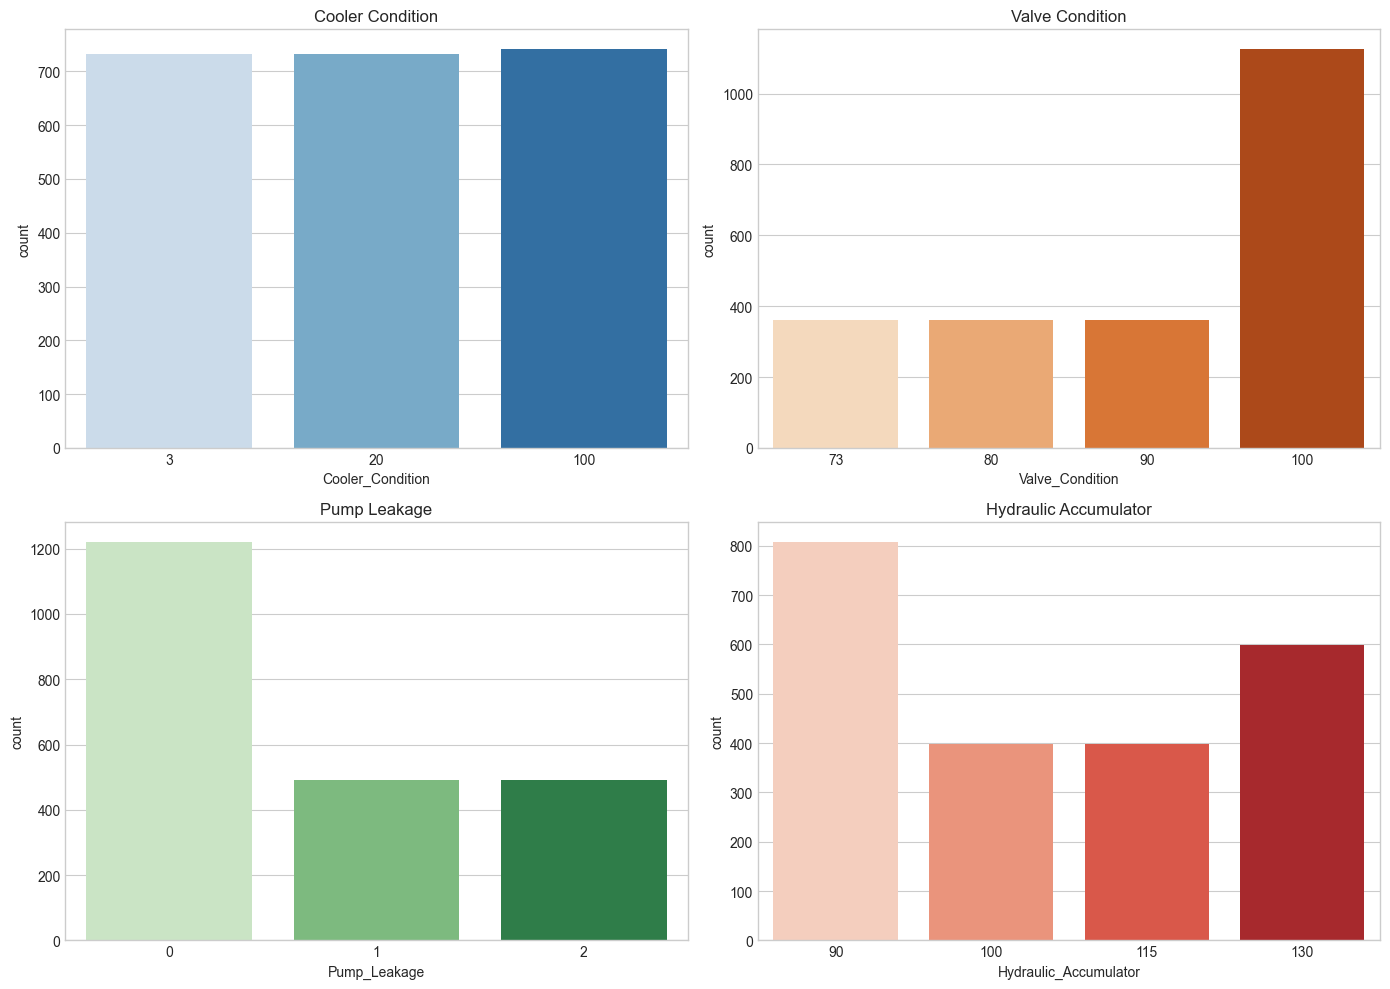

In [51]:
# Plot Target Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(x='Cooler_Condition', data=profile, ax=axes[0,0], palette='Blues').set_title('Cooler Condition')
sns.countplot(x='Valve_Condition', data=profile, ax=axes[0,1], palette='Oranges').set_title('Valve Condition')
sns.countplot(x='Pump_Leakage', data=profile, ax=axes[1,0], palette='Greens').set_title('Pump Leakage')
sns.countplot(x='Hydraulic_Accumulator', data=profile, ax=axes[1,1], palette='Reds').set_title('Hydraulic Accumulator')
plt.tight_layout()
plt.show()


In [52]:
# Sensor files dictionary mapped to their sampling rates
sensor_files = {
    'PS1': 100, 'PS2': 100, 'PS3': 100, 'PS4': 100, 'PS5': 100, 'PS6': 100, 'EPS1': 100,
    'FS1': 10, 'FS2': 10,
    'TS1': 1, 'TS2': 1, 'TS3': 1, 'TS4': 1,
    'VS1': 1, 'CE': 1, 'CP': 1, 'SE': 1
}


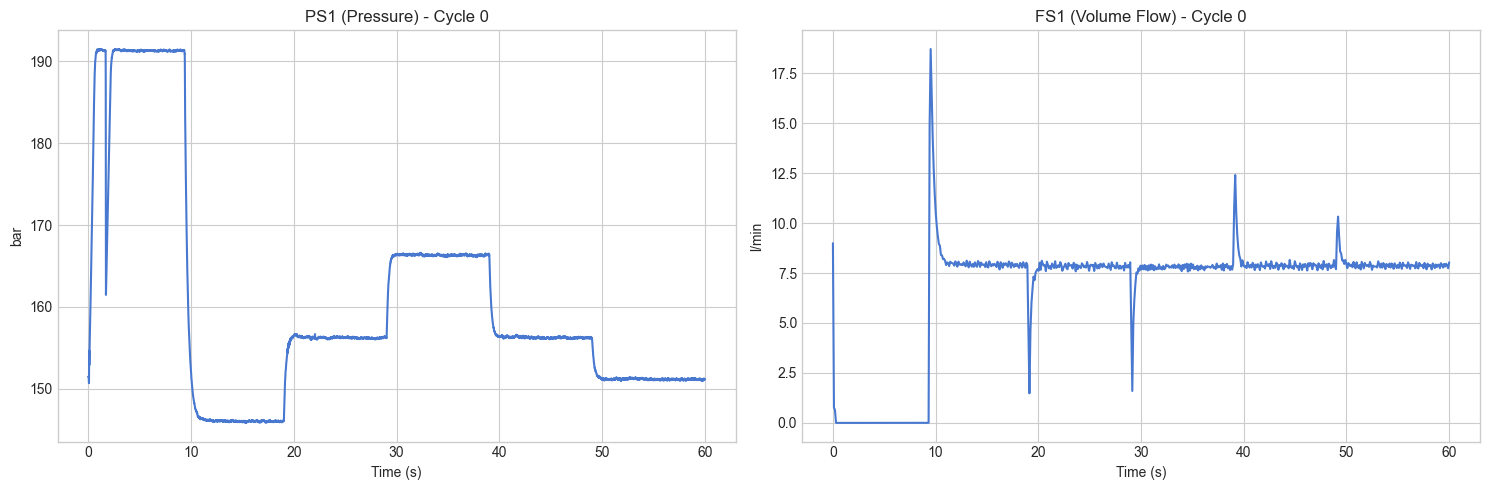

In [53]:
# Plot cycle 0 for PS1 (Pressure) and FS1 (Volume Flow)
plt.figure(figsize=(15, 5))

# Plot PS1 (100 Hz -> 6000 points per cycle)
ps1 = pd.read_csv('Datasets/PS1.csv', sep='\t', header=None)
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0, 60, 6000), ps1.iloc[0, :])
plt.title('PS1 (Pressure) - Cycle 0')
plt.xlabel('Time (s)')
plt.ylabel('bar')

# Plot FS1 (10 Hz -> 600 points per cycle)
fs1 = pd.read_csv('Datasets/FS1.csv', sep='\t', header=None)
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0, 60, 600), fs1.iloc[0, :])
plt.title('FS1 (Volume Flow) - Cycle 0')
plt.xlabel('Time (s)')
plt.ylabel('l/min')

plt.tight_layout()
plt.show()


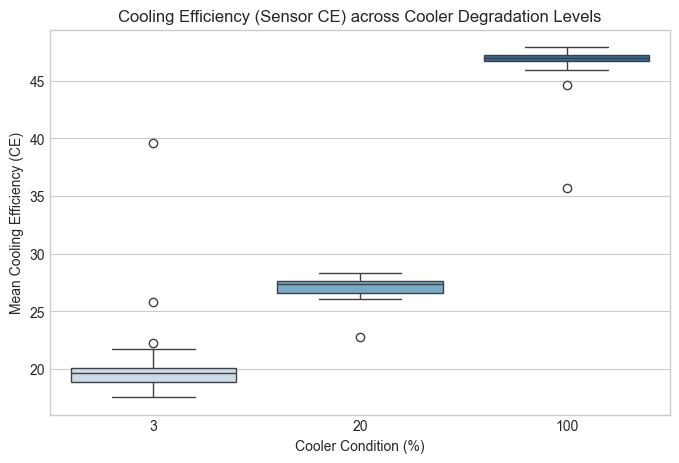

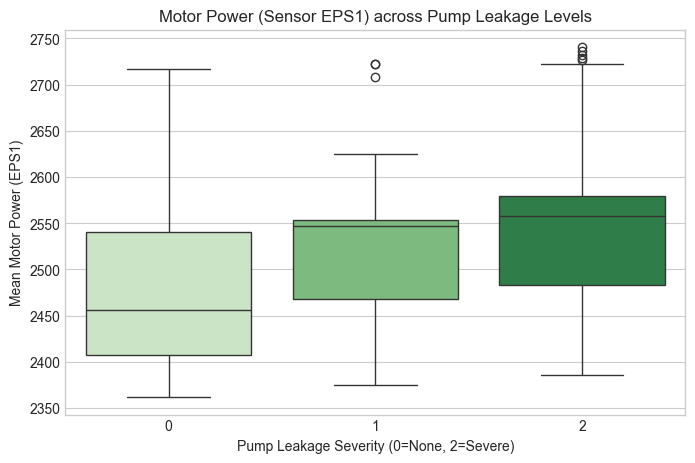

In [54]:
# EDA: Sensor signal across degradation levels
# Let's see how the Cooling Efficiency (CE) sensor changes with Cooler Condition
ce_sensor = pd.read_csv('Datasets/CE.csv', sep='\t', header=None)

temp_df = pd.DataFrame({
    'Mean_Cooling_Efficiency': ce_sensor.mean(axis=1),
    'Cooler_Condition': profile['Cooler_Condition']
})

plt.figure(figsize=(8, 5))
sns.boxplot(x='Cooler_Condition', y='Mean_Cooling_Efficiency', data=temp_df, palette='Blues')
plt.title('Cooling Efficiency (Sensor CE) across Cooler Degradation Levels')
plt.xlabel('Cooler Condition (%)')
plt.ylabel('Mean Cooling Efficiency (CE)')
plt.show()

# Let's see how Motor Power (EPS1) changes with Pump Leakage
eps1_sensor = pd.read_csv('Datasets/EPS1.csv', sep='\t', header=None)
temp_df2 = pd.DataFrame({
    'Mean_Motor_Power': eps1_sensor.mean(axis=1),
    'Pump_Leakage': profile['Pump_Leakage']
})

plt.figure(figsize=(8, 5))
sns.boxplot(x='Pump_Leakage', y='Mean_Motor_Power', data=temp_df2, palette='Greens')
plt.title('Motor Power (Sensor EPS1) across Pump Leakage Levels')
plt.xlabel('Pump Leakage Severity (0=None, 2=Severe)')
plt.ylabel('Mean Motor Power (EPS1)')
plt.show()


## 3. Feature Extraction\nWe engineer per-cycle statistical features (mean, median, std, min, max) for each sensor.

In [55]:
# Feature Engineering: compute per-cycle statistical features
def extract_features(sensor_name):
    filepath = f'Datasets/{sensor_name}.csv'
    df = pd.read_csv(filepath, sep='\t', header=None)
    
    # Calculate cycle-wise features
    features = pd.DataFrame()
    features[f'{sensor_name}_mean'] = df.mean(axis=1)
    features[f'{sensor_name}_median'] = df.median(axis=1)
    features[f'{sensor_name}_std'] = df.std(axis=1)
    features[f'{sensor_name}_min'] = df.min(axis=1)
    features[f'{sensor_name}_max'] = df.max(axis=1)
    features[f'{sensor_name}_range'] = df.max(axis=1) - df.min(axis=1)
    features[f'{sensor_name}_rate_of_change'] = df.diff(axis=1).mean(axis=1)
    
    return features

all_features = []
for sensor in sensor_files.keys():
    print(f"Processing {sensor}...")
    sensor_features = extract_features(sensor)
    all_features.append(sensor_features)

# Combine all features into a single dataframe
X = pd.concat(all_features, axis=1)
print(f"\nExtracted features shape: {X.shape}")
display(X.head())


Processing PS1...
Processing PS2...
Processing PS3...
Processing PS4...
Processing PS5...
Processing PS6...
Processing EPS1...
Processing FS1...
Processing FS2...
Processing TS1...
Processing TS2...
Processing TS3...
Processing TS4...
Processing VS1...
Processing CE...
Processing CP...
Processing SE...

Extracted features shape: (2205, 119)


,PS1_mean,PS1_median,PS1_std,PS1_min,PS1_max,PS1_range,PS1_rate_of_change,PS2_mean,PS2_median,PS2_std,...,CP_max,CP_range,CP_rate_of_change,SE_mean,SE_median,SE_std,SE_min,SE_max,SE_range,SE_rate_of_change
0,160.673492,156.25,13.939309,145.83,191.51,45.68,-0.000047,109.466914,129.365,47.114508,...,2.188,0.805,-0.013576,59.157183,68.5145,23.763984,0.0,79.568,79.568,0.003814
1,160.603320,156.06,14.118967,145.73,191.47,45.74,-0.000042,109.354890,129.385,47.045611,...,1.414,0.267,-0.004237,59.335617,68.5360,23.857918,0.0,80.441,80.441,0.005610
2,160.347720,155.72,14.192619,145.37,191.41,46.04,-0.000032,109.158845,129.325,46.992060,...,1.159,0.083,-0.000949,59.543150,68.8530,23.923381,0.0,80.824,80.824,0.000559
3,160.188088,155.56,14.227803,145.14,191.34,46.20,-0.000033,109.064807,128.865,46.972221,...,1.107,0.085,-0.000169,59.794900,69.0060,24.023005,0.0,80.930,80.930,0.004068
4,160.000472,155.34,14.276434,144.95,191.41,46.46,-0.000037,108.931434,129.000,46.874946,...,1.106,0.090,0.000339,59.455267,69.0130,23.972262,0.0,81.100,81.100,0.001763


## 4. Normalization\nScale the features for classical ML models.

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

display(X_scaled.head())


,PS1_mean,PS1_median,PS1_std,PS1_min,PS1_max,PS1_range,PS1_rate_of_change,PS2_mean,PS2_median,PS2_std,...,CP_max,CP_range,CP_rate_of_change,SE_mean,SE_median,SE_std,SE_min,SE_max,SE_range,SE_rate_of_change
0,0.040052,-0.128150,-0.656258,1.073368,1.004103,-1.072761,-0.059970,0.017452,0.198151,-0.190038,...,1.193189,21.675755,-20.591999,0.431929,0.384614,-0.202694,0.0,-0.063981,-0.063981,0.037570
1,0.025116,-0.145978,-0.569368,1.027831,0.937749,-1.036019,-0.053513,-0.005018,0.203917,-0.211100,...,-1.586578,5.441365,-6.372276,0.451847,0.385852,-0.153763,0.0,0.091880,0.091880,0.055272
2,-0.029286,-0.177882,-0.533747,0.863898,0.838219,-0.852309,-0.040601,-0.044341,0.186620,-0.227470,...,-2.502393,-0.110917,-1.365694,0.475014,0.404107,-0.119662,0.0,0.160258,0.160258,0.005505
3,-0.063262,-0.192895,-0.516730,0.759163,0.722101,-0.754330,-0.042753,-0.063204,0.054007,-0.233535,...,-2.689147,-0.050566,-0.178567,0.503117,0.412918,-0.067767,0.0,0.179183,0.179183,0.040075
4,-0.103194,-0.213538,-0.493210,0.672643,0.838219,-0.595115,-0.047057,-0.089956,0.092926,-0.263272,...,-2.692739,0.100311,0.595647,0.465204,0.413321,-0.094199,0.0,0.209534,0.209534,0.017362


## 5. Prepare Target Variables

In [57]:
# Map target variables
y_cooler = profile['Cooler_Condition']
y_valve = profile['Valve_Condition']
y_pump = profile['Pump_Leakage']
y_accumulator = profile['Hydraulic_Accumulator']

print("Targets ready for modeling.")


Targets ready for modeling.


## 6. Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split

# Create train/test splits for each target
X_train, X_test, y_cooler_train, y_cooler_test = train_test_split(X_scaled, y_cooler, test_size=0.3, random_state=42)
_, _, y_valve_train, y_valve_test = train_test_split(X_scaled, y_valve, test_size=0.3, random_state=42)
_, _, y_pump_train, y_pump_test = train_test_split(X_scaled, y_pump, test_size=0.3, random_state=42)
_, _, y_acc_train, y_acc_test = train_test_split(X_scaled, y_accumulator, test_size=0.3, random_state=42)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (1543, 119), Test shape: (662, 119)


## 7. Model Building (Single Target)

In [59]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


Training Random Forest...
Training SVM...
Training Gradient Boosting...

Random Forest - Cooler Condition Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00       230
          20       1.00      1.00      1.00       210
         100       1.00      1.00      1.00       222

    accuracy                           1.00       662
   macro avg       1.00      1.00      1.00       662
weighted avg       1.00      1.00      1.00       662



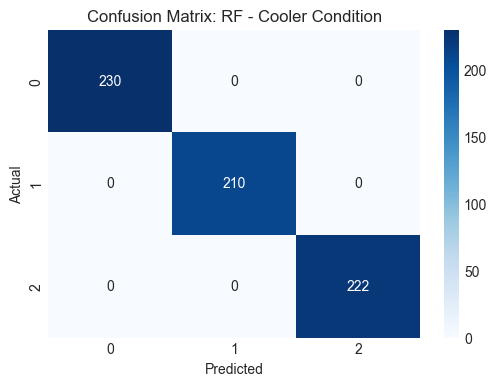

In [60]:
# Example: Training Models for Cooler Condition
rf_cooler = RandomForestClassifier(n_estimators=100, random_state=42)
svm_cooler = SVC(kernel='rbf', probability=True, random_state=42)
gb_cooler = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train models
print("Training Random Forest...")
rf_cooler.fit(X_train, y_cooler_train)
print("Training SVM...")
svm_cooler.fit(X_train, y_cooler_train)
print("Training Gradient Boosting...")
gb_cooler.fit(X_train, y_cooler_train)

# Evaluate Random Forest
rf_pred = rf_cooler.predict(X_test)
print("\nRandom Forest - Cooler Condition Accuracy:", accuracy_score(y_cooler_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_cooler_test, rf_pred))

# Confusion Matrix for RF
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_cooler_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: RF - Cooler Condition")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 8. Multi-output Classification

In [61]:
from sklearn.multioutput import MultiOutputClassifier

# Prepare combined target matrix
y_multi = pd.concat([y_cooler, y_valve, y_pump, y_accumulator], axis=1)
y_multi_train, y_multi_test = train_test_split(y_multi, test_size=0.3, random_state=42)

# Initialize Multi-Output Random Forest
rf_multi = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))

print("Training Multi-Output Random Forest...")
rf_multi.fit(X_train, y_multi_train)
y_multi_pred = rf_multi.predict(X_test)

# Evaluate
print("Multi-Output Model trained. Evaluating per target:")
for i, col in enumerate(y_multi.columns):
    acc = accuracy_score(y_multi_test.iloc[:, i], y_multi_pred[:, i])
    print(f"{col} Accuracy: {acc:.4f}")


Training Multi-Output Random Forest...
Multi-Output Model trained. Evaluating per target:
Cooler_Condition Accuracy: 1.0000
Valve_Condition Accuracy: 0.9471
Pump_Leakage Accuracy: 0.9940
Hydraulic_Accumulator Accuracy: 0.9728


## 9. Feature Importance Analysis

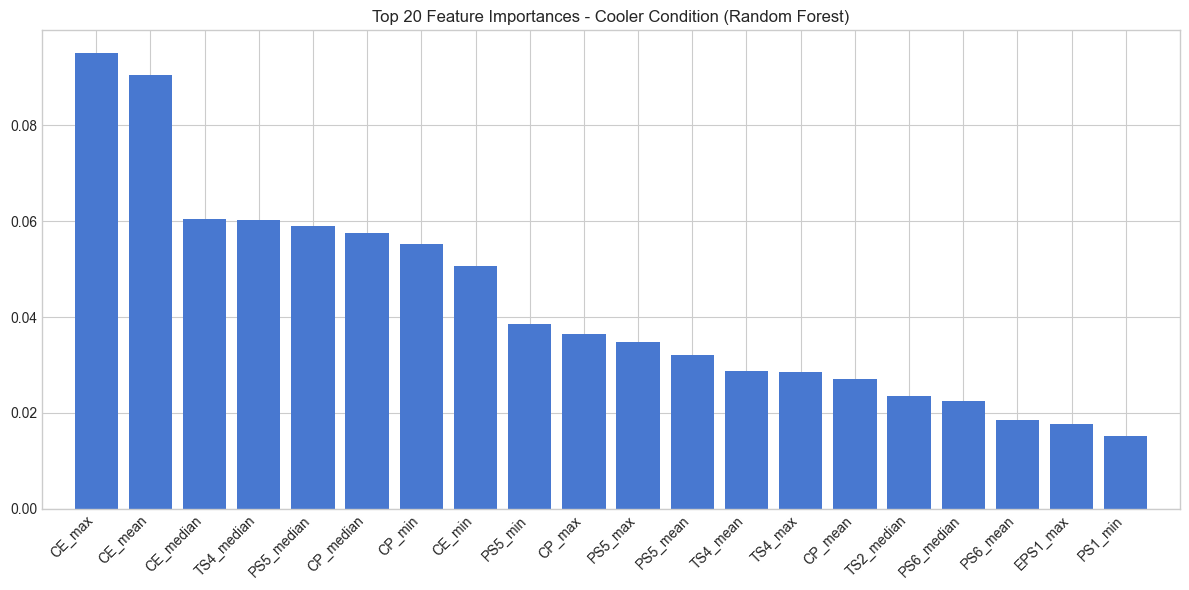

In [62]:
# Feature Importance from the Cooler Random Forest Model
importances = rf_cooler.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top 20 features
plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importances - Cooler Condition (Random Forest)")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [X.columns[i] for i in indices[:20]], rotation=45, ha='right')
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()


## 10. ROC-AUC Analysis

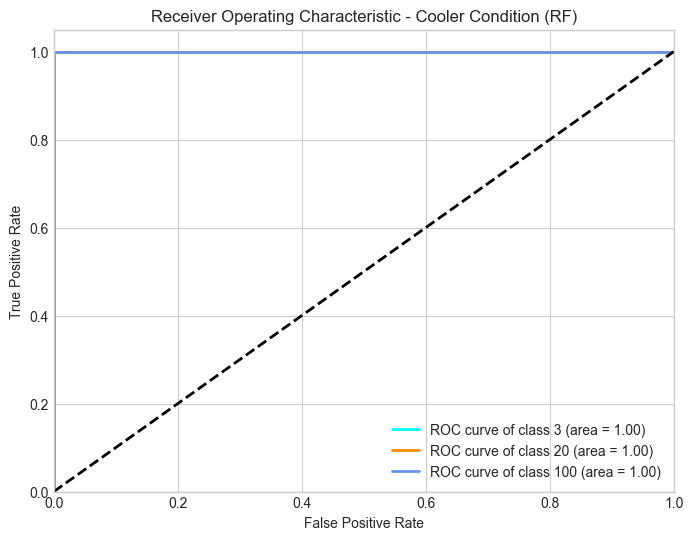

In [63]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize the output for multi-class ROC AUC
classes = np.unique(y_cooler_test)
y_test_bin = label_binarize(y_cooler_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Predict probabilities
y_score = rf_cooler.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Cooler Condition (RF)')
plt.legend(loc="lower right")
plt.show()


## 11. Analysis for Remaining Components (Valve, Pump, Accumulator)


Processing target: Valve_Condition


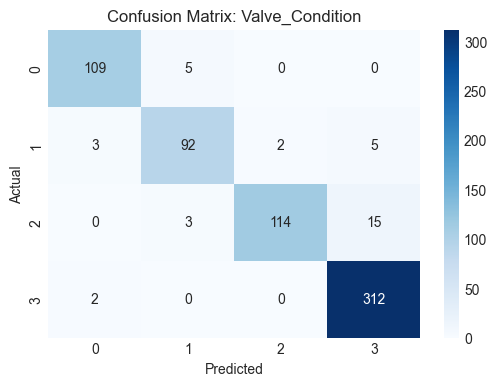

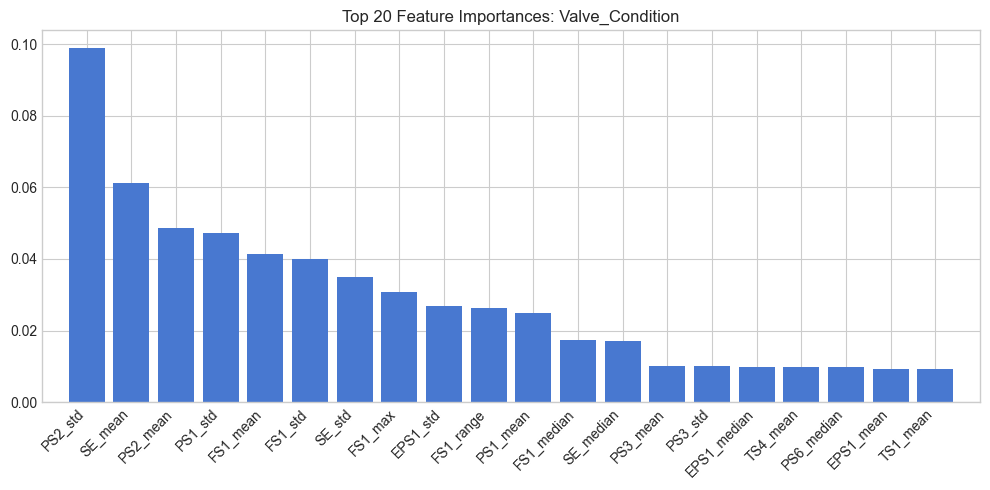

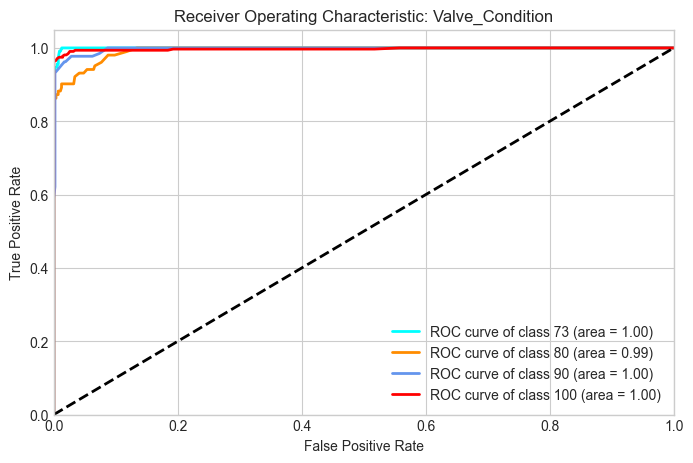


Processing target: Pump_Leakage


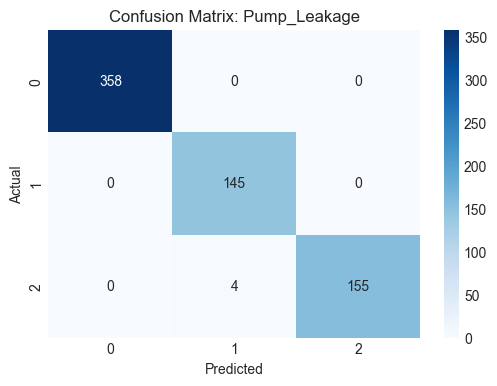

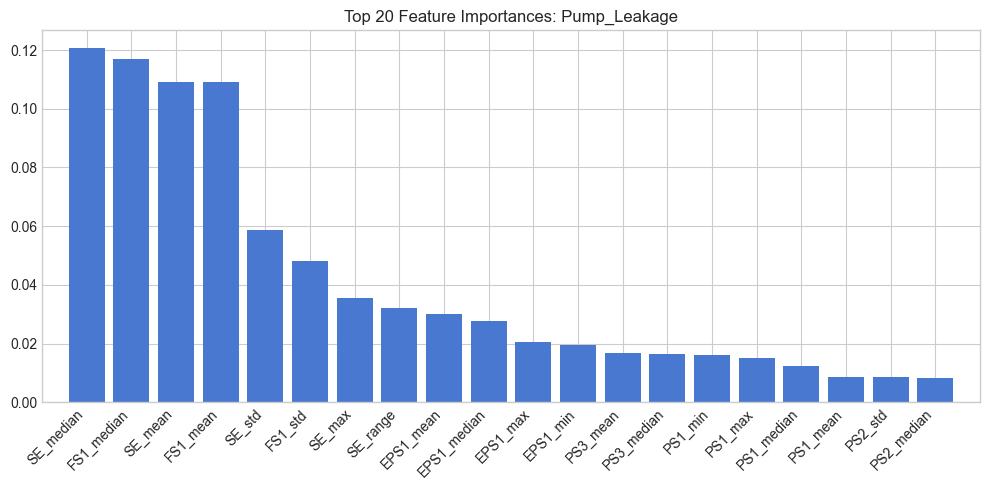

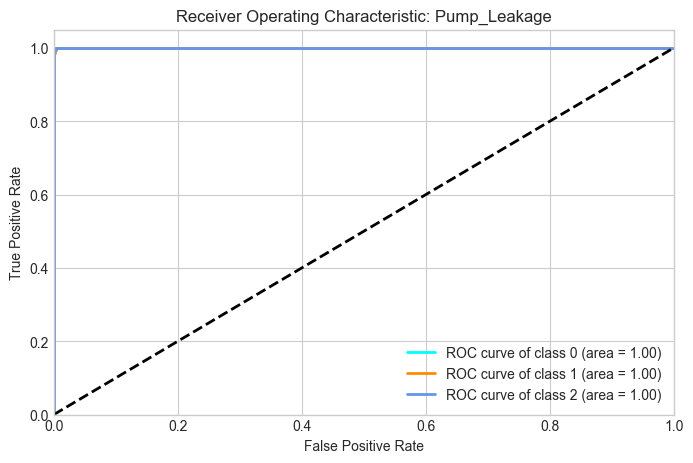


Processing target: Hydraulic_Accumulator


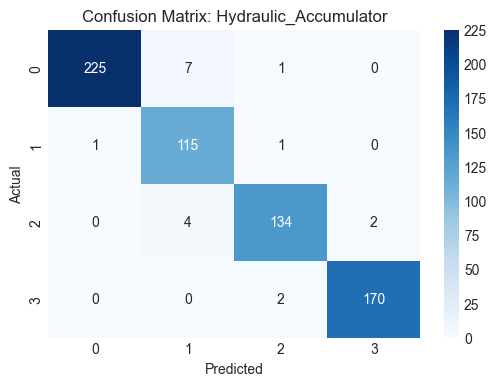

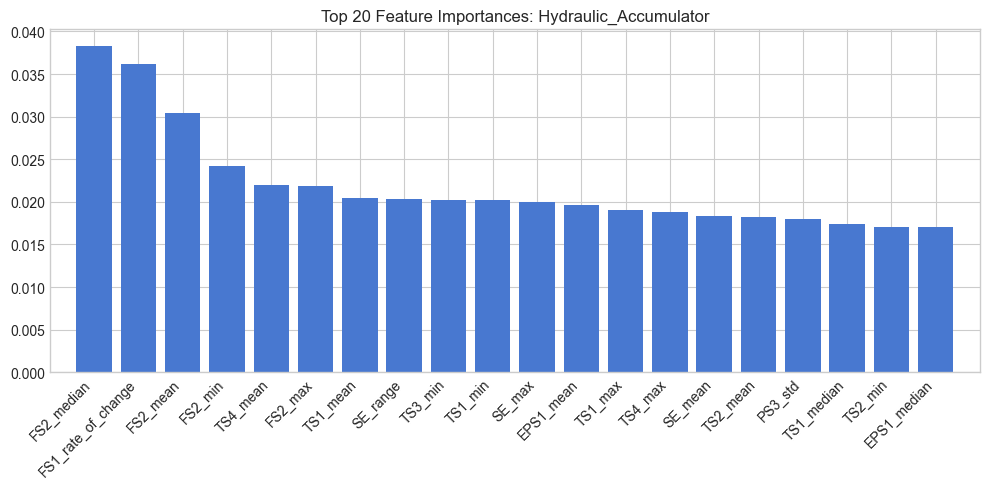

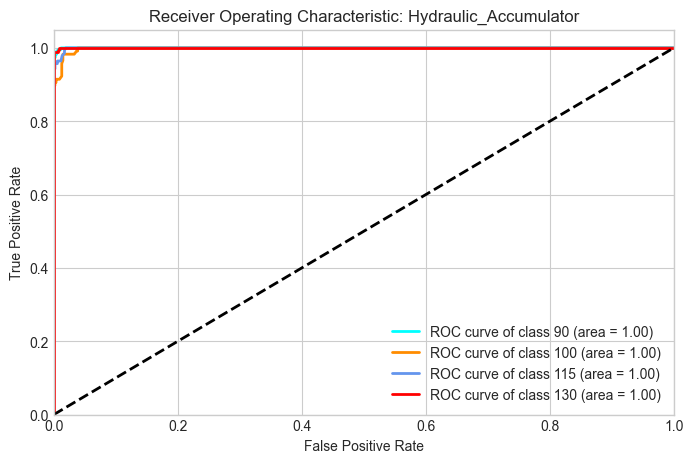

In [64]:
# Training and Evaluation for Valve, Pump, and Accumulator
remaining_targets = {
    'Valve_Condition': y_valve_train,
    'Pump_Leakage': y_pump_train,
    'Hydraulic_Accumulator': y_acc_train
}

remaining_test = {
    'Valve_Condition': y_valve_test,
    'Pump_Leakage': y_pump_test,
    'Hydraulic_Accumulator': y_acc_test
}

for target_name in remaining_targets.keys():
    print(f"\n{'='*50}")
    print(f"Processing target: {target_name}")
    print(f"{'='*50}")
    
    y_tr = remaining_targets[target_name]
    y_te = remaining_test[target_name]
    
    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_tr)
    
    # Predict
    y_pred = rf.predict(X_test)
    y_score = rf.predict_proba(X_test)
    
    # 1. Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {target_name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # 2. Feature Importance
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 5))
    plt.title(f"Top 20 Feature Importances: {target_name}")
    plt.bar(range(20), importances[indices][:20], align="center")
    plt.xticks(range(20), [X.columns[i] for i in indices[:20]], rotation=45, ha='right')
    plt.xlim([-1, 20])
    plt.tight_layout()
    plt.show()
    
    # 3. ROC-AUC
    classes = np.unique(y_te)
    y_test_bin = label_binarize(y_te, classes=classes)
    n_classes = y_test_bin.shape[1]
    
    if n_classes == 1:
        n_classes = 2
        y_test_bin = np.hstack((1 - y_test_bin, y_test_bin))
        
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    plt.figure(figsize=(8, 5))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {classes[i]} (area = {roc_auc[i]:0.2f})')
                 
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic: {target_name}')
    plt.legend(loc="lower right")
    plt.show()
